# Figure 5 — T Cell Exhaustion in MBM
**Paper:** Biermann et al. 2022 *Cell*  
**Original code:** `T_cell_analysis/tcells_umaps_violins_diffusion.R`, `DEG_SCvSN_TOX_tcells.R`

| Panel | Content |
|-------|---------|
| 5A | T/NK cell UMAP (organ / fine subtype) |
| 5B | Key T-cell marker violins (CD8/CD4/TOX/checkpoint) |
| 5C | Exhaustion score: MBM vs MPM TOX+ CD8 cells |
| 5D | Diffusion map: TCF7+ → TOX+ CD8 T cell trajectory |
| 5E | Clone size (Expanded vs Non-expanded) on UMAP |
| 5F | HLA gene expression: MBM vs MPM TOX+ cells |
| 5G | Checkpoint gene co-expression heatmap |

## 0 · Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, scanpy as sc, os
from scipy import stats
from sklearn.manifold import TSNE
np.random.seed(42)
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')
os.makedirs('outputs', exist_ok=True)

COL_ORGAN  = {'Brain':'#A80D11','Peripheral':'#008DB8'}
COL_CYCLE  = {'Expanded':'#C82F71','Non-expanded':'#7473A6'}
TCELL_COLORS = {
    'CD8+ T cells TOX+' :'#1F77B4','CD8+ T cells TCF7+':'#AEC7E8',
    'CD4+ T cells'      :'#2CA02C','Tregs'              :'#98DF8A',
    'NK cells'          :'#8C564B',
}
DATA_PATH = 'data/mbpm_immune_synthetic.h5ad'
print('Setup complete.')

Setup complete.


## 1 · Load & Subset T/NK Cells

In [2]:
if os.path.exists('outputs/adata_immune_fig4.h5ad'):
    adata_all = sc.read_h5ad('outputs/adata_immune_fig4.h5ad')
    print('Loaded from Figure 4 output.')
else:
    if not os.path.exists(DATA_PATH):
        exec(open('generate_immune_data.py').read())
    adata_all = sc.read_h5ad(DATA_PATH)
    sc.pp.normalize_total(adata_all, target_sum=1e4)
    sc.pp.log1p(adata_all)
    adata_all.raw = adata_all

# Subset to T/NK cells
adata_t = adata_all[adata_all.obs['cell_type_main']=='T/NK cells'].copy()
print(f'T/NK cells: {adata_t.n_obs:,}')
print(adata_t.obs['cell_type_fine'].value_counts().to_string())

Loaded from Figure 4 output.


T/NK cells: 3,120
cell_type_fine
CD8+ T cells TOX+     1080
CD8+ T cells TCF7+     720
CD4+ T cells           600
NK cells               420
Tregs                  300


## 2 · T-Cell Integration & UMAP
Mirrors `tcells_umaps_violins_diffusion.R` — dims=1:20, re-integration per patient.

In [3]:
# Check if already normalised
_max = adata_t.X.max() if hasattr(adata_t.X,'max') else adata_t.X.toarray().max()
if _max > 50:
    sc.pp.normalize_total(adata_t, target_sum=1e4)
    sc.pp.log1p(adata_t)
if adata_t.raw is None: adata_t.raw = adata_t

sc.pp.highly_variable_genes(adata_t, n_top_genes=min(2000, adata_t.n_vars-1))
sc.pp.scale(adata_t, max_value=10)
sc.tl.pca(adata_t, n_comps=min(50, adata_t.n_obs-2), use_highly_variable=True)

import harmonypy as hm
ho = hm.run_harmony(adata_t.obsm['X_pca'], adata_t.obs, ['patient'],
                    random_state=42, verbose=False)
adata_t.obsm['X_pca_harmony'] = ho.Z_corr
sc.pp.neighbors(adata_t, use_rep='X_pca_harmony', n_pcs=20, random_state=42)
sc.tl.umap(adata_t, spread=1.5, min_dist=0.1, random_state=42)
print('T-cell UMAP done. Shape:', adata_t.obsm['X_umap'].shape)

T-cell UMAP done. Shape: (3120, 2)


## 3 · Fig 5A — T/NK Cell UMAP Panels

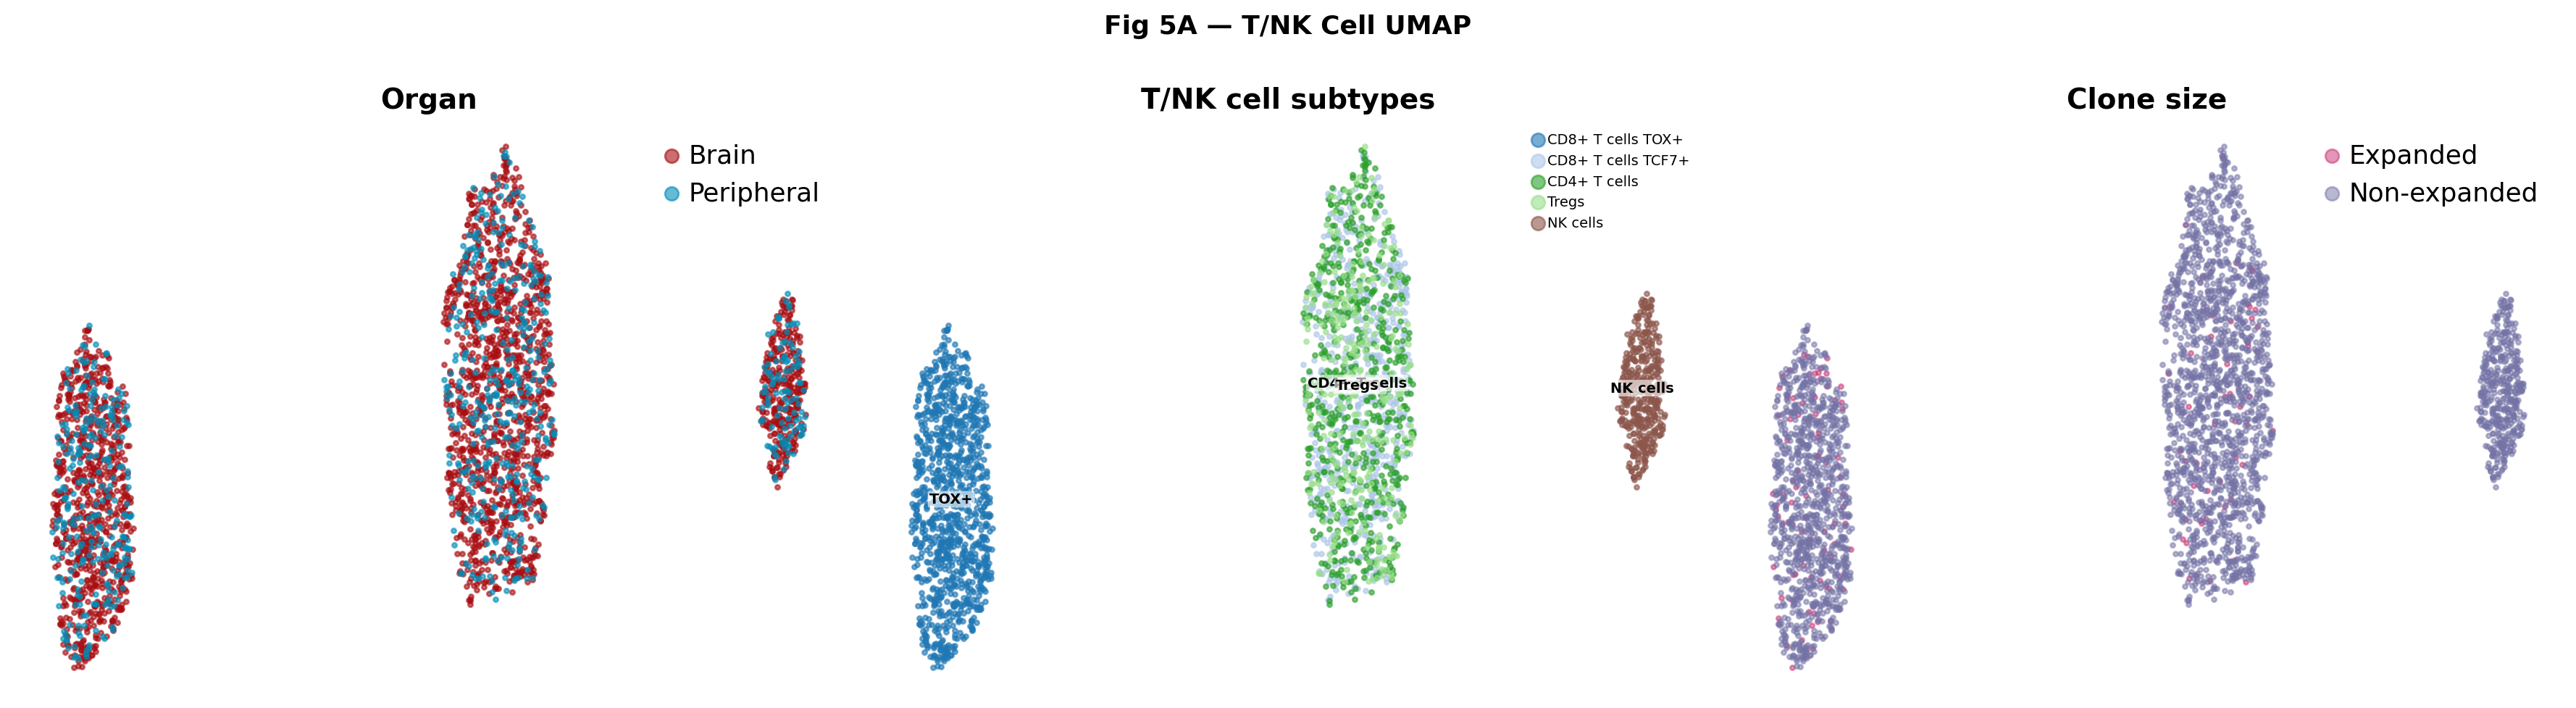

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Organ
for org, col in COL_ORGAN.items():
    mask = adata_t.obs['organ'] == org
    axes[0].scatter(adata_t.obsm['X_umap'][mask,0], adata_t.obsm['X_umap'][mask,1],
                   c=col, s=5, alpha=0.6, label=org, rasterized=True)
axes[0].set_title('Organ', fontweight='bold'); axes[0].axis('off')
axes[0].legend(markerscale=3, frameon=False)

# Fine subtype
for ct, col in TCELL_COLORS.items():
    mask = adata_t.obs['cell_type_fine'] == ct
    if mask.sum()==0: continue
    axes[1].scatter(adata_t.obsm['X_umap'][mask,0], adata_t.obsm['X_umap'][mask,1],
                   c=col, s=5, alpha=0.6, label=ct, rasterized=True)
    cx = adata_t.obsm['X_umap'][mask,0].mean()
    cy = adata_t.obsm['X_umap'][mask,1].mean()
    axes[1].text(cx, cy, ct.replace('CD8+ T cells ',''), fontsize=7,
                fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.1',fc='white',alpha=0.6,lw=0))
axes[1].set_title('T/NK cell subtypes', fontweight='bold'); axes[1].axis('off')
axes[1].legend(markerscale=3, frameon=False, fontsize=7, bbox_to_anchor=(1,1))

# Clone size (sc only)
for cs, col in COL_CYCLE.items():
    mask = adata_t.obs['clone_size'] == cs
    if mask.sum()==0: continue
    axes[2].scatter(adata_t.obsm['X_umap'][mask,0], adata_t.obsm['X_umap'][mask,1],
                   c=col, s=5, alpha=0.5, label=cs, rasterized=True)
axes[2].set_title('Clone size', fontweight='bold'); axes[2].axis('off')
axes[2].legend(markerscale=3, frameon=False)

plt.suptitle('Fig 5A — T/NK Cell UMAP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig5A_tcell_umap.pdf', bbox_inches='tight')
plt.show()

## 4 · Fig 5B — Key T-Cell Marker Violin Plots
Mirrors `VlnPlot(sn, features=genes, group.by='cell_type_fine', split.by='organ')` from the paper.

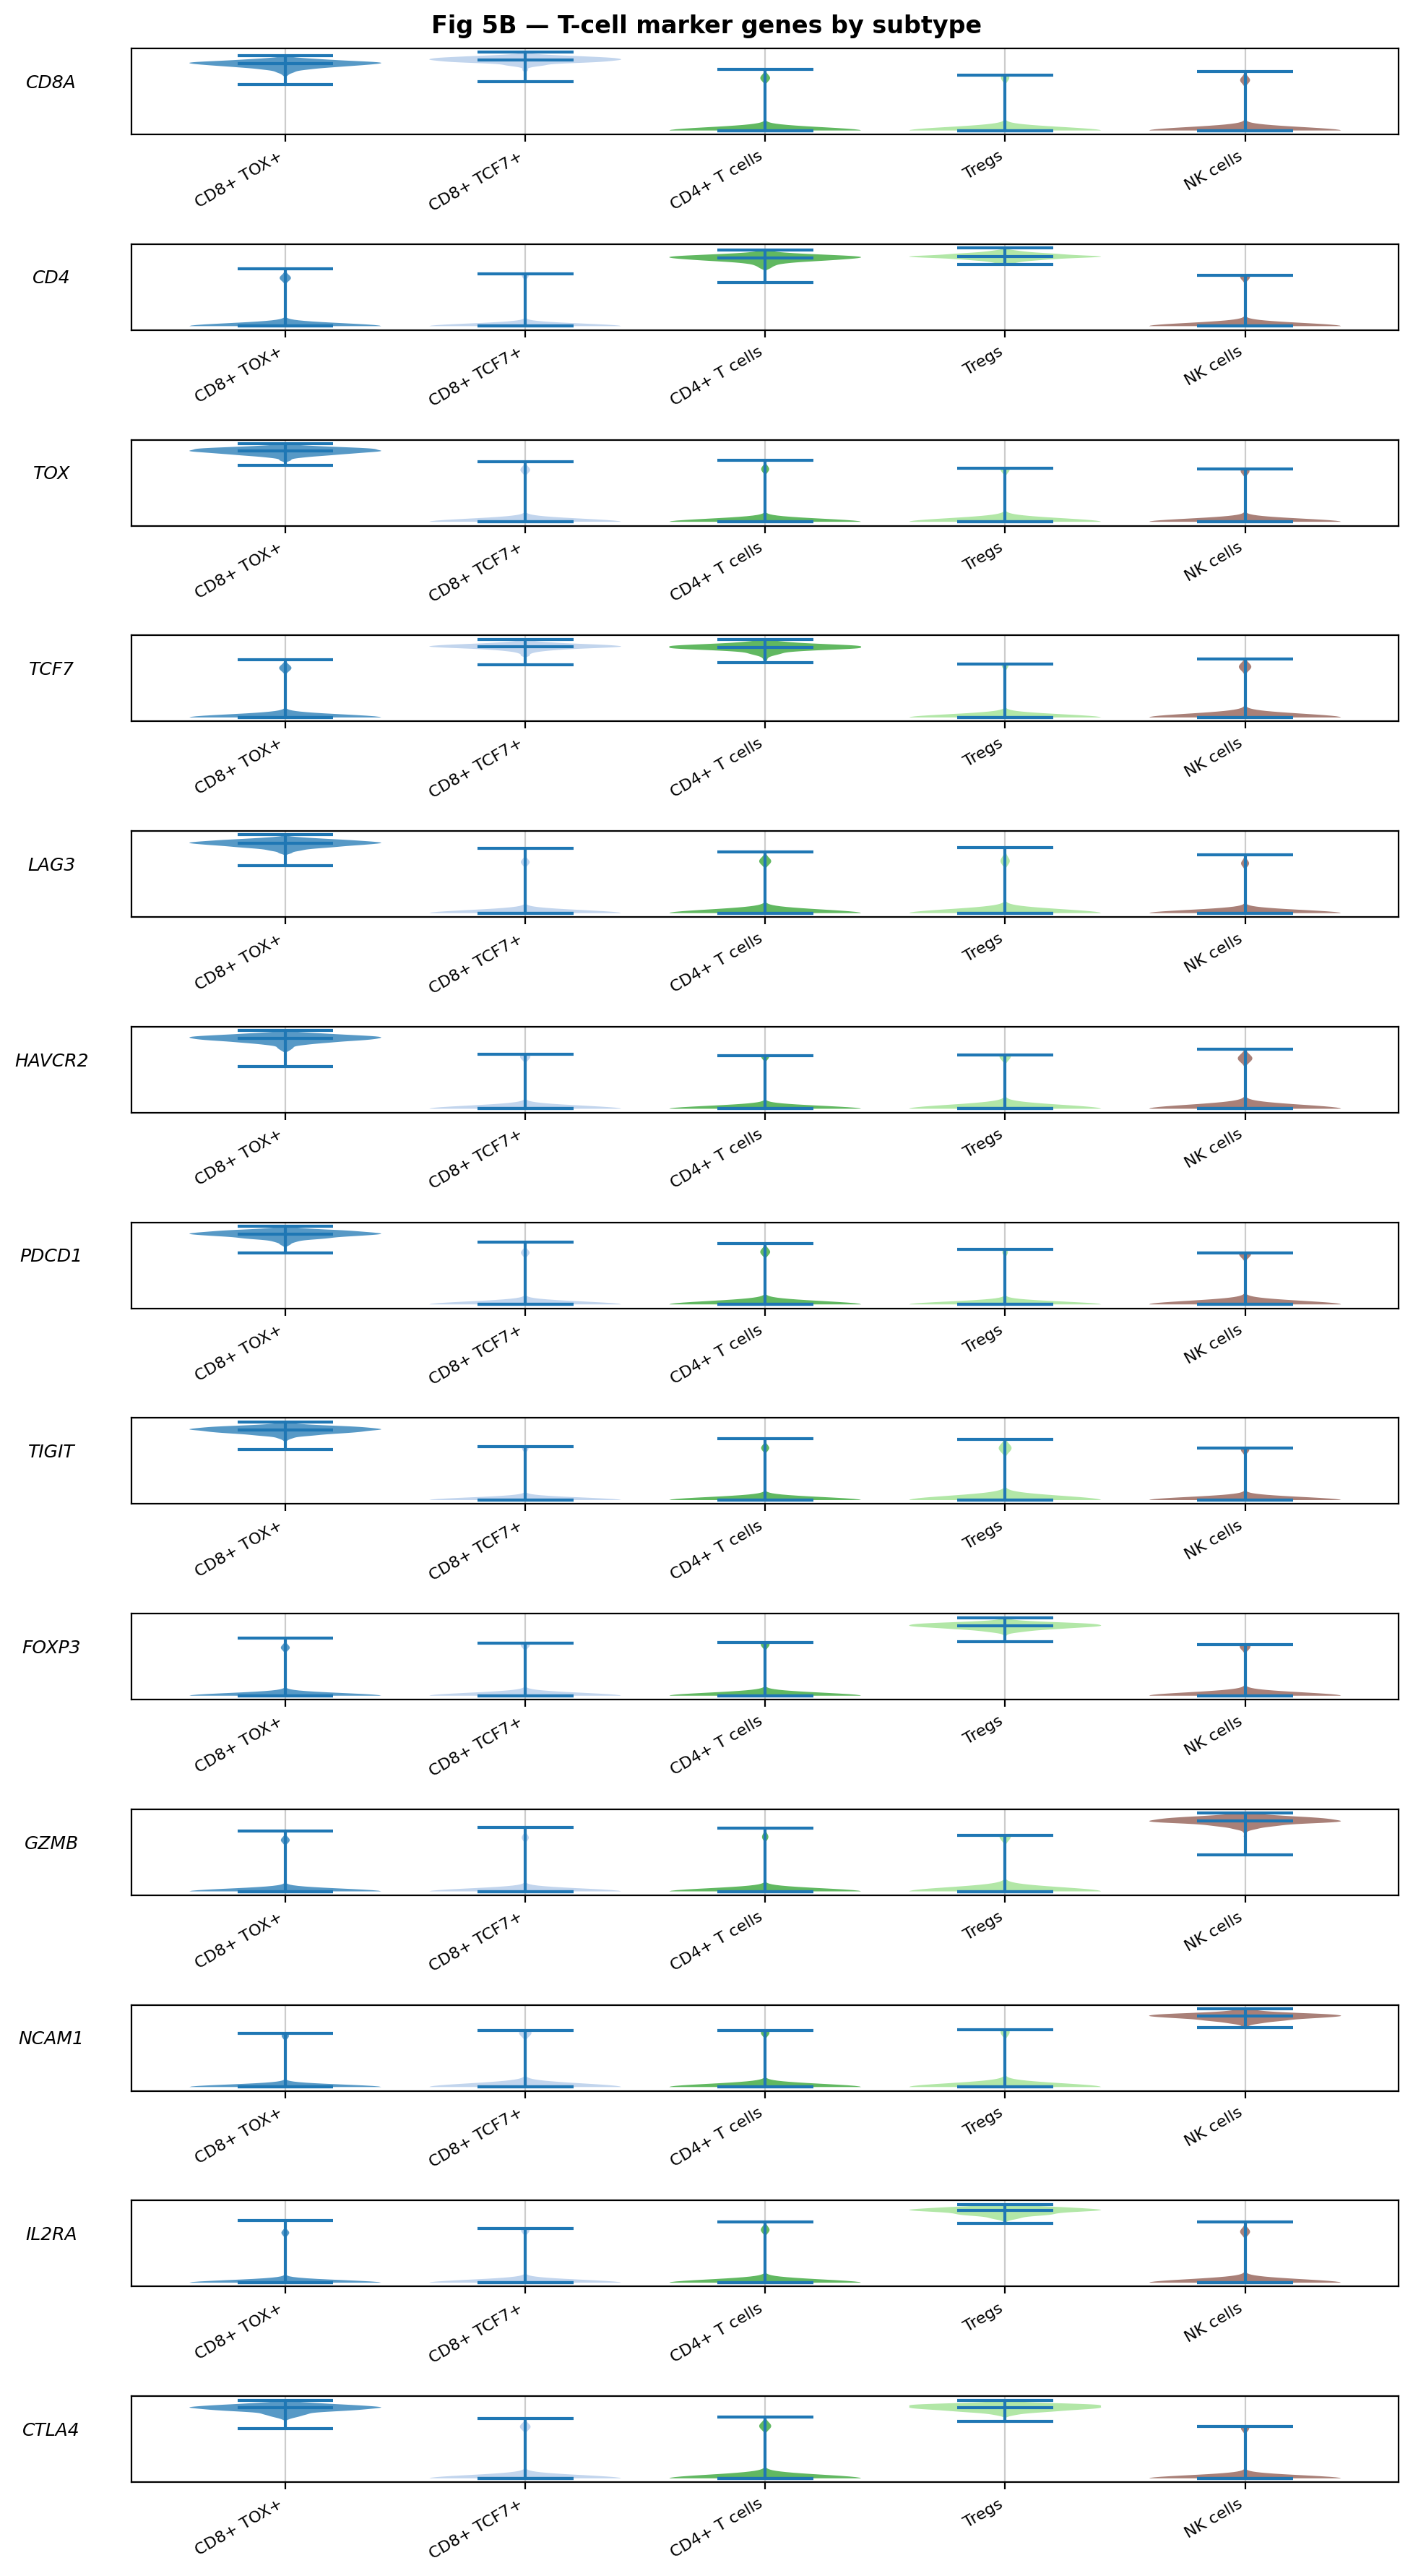

In [5]:
# Marker genes from original T cell script
marker_genes = ['CD8A','CD4','TOX','TCF7','LAG3','HAVCR2','PDCD1',
                'TIGIT','FOXP3','GZMB','NCAM1','IL2RA','CTLA4']
marker_genes = [g for g in marker_genes if g in adata_t.raw.var_names]

tmp = adata_t.raw.to_adata()
subtypes_ordered = ['CD8+ T cells TOX+','CD8+ T cells TCF7+','CD4+ T cells','Tregs','NK cells']

fig, axes = plt.subplots(len(marker_genes), 1, figsize=(10, len(marker_genes)*1.4))
if len(marker_genes)==1: axes=[axes]

for ax, gene in zip(axes, marker_genes):
    data_by_ct, labels = [], []
    for ct in subtypes_ordered:
        mask = adata_t.obs['cell_type_fine'] == ct
        if mask.sum()==0: continue
        expr = tmp[mask, gene].X
        if hasattr(expr,'toarray'): expr=expr.toarray().flatten()
        else: expr=np.array(expr).flatten()
        data_by_ct.append(expr); labels.append(ct.replace('CD8+ T cells ','CD8+ '))
    if data_by_ct:
        vp = ax.violinplot(data_by_ct, positions=range(len(data_by_ct)),
                           showmedians=True, widths=0.8)
        for i,(body,ct) in enumerate(zip(vp['bodies'], labels)):
            col = list(TCELL_COLORS.values())[i] if i<len(TCELL_COLORS) else '#888888'
            body.set_facecolor(col); body.set_alpha(0.75)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(gene, fontsize=9, fontstyle='italic', rotation=0, labelpad=40)
        ax.tick_params(left=False); ax.set_yticks([])

plt.suptitle('Fig 5B — T-cell marker genes by subtype', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig5B_tcell_markers.pdf', bbox_inches='tight')
plt.show()

## 5 · Fig 5C — T Cell Exhaustion: MBM vs MPM TOX+ CD8 Cells

Exhaustion genes: ['TOX', 'TOX2', 'LAG3', 'HAVCR2', 'PDCD1', 'TIGIT', 'ENTPD1', 'CTLA4', 'BATF']
MBM TOX+ exhaustion median = 5.6477
MPM TOX+ exhaustion median = 5.3607
Wilcoxon (MBM > MPM): p = 0.000e+00


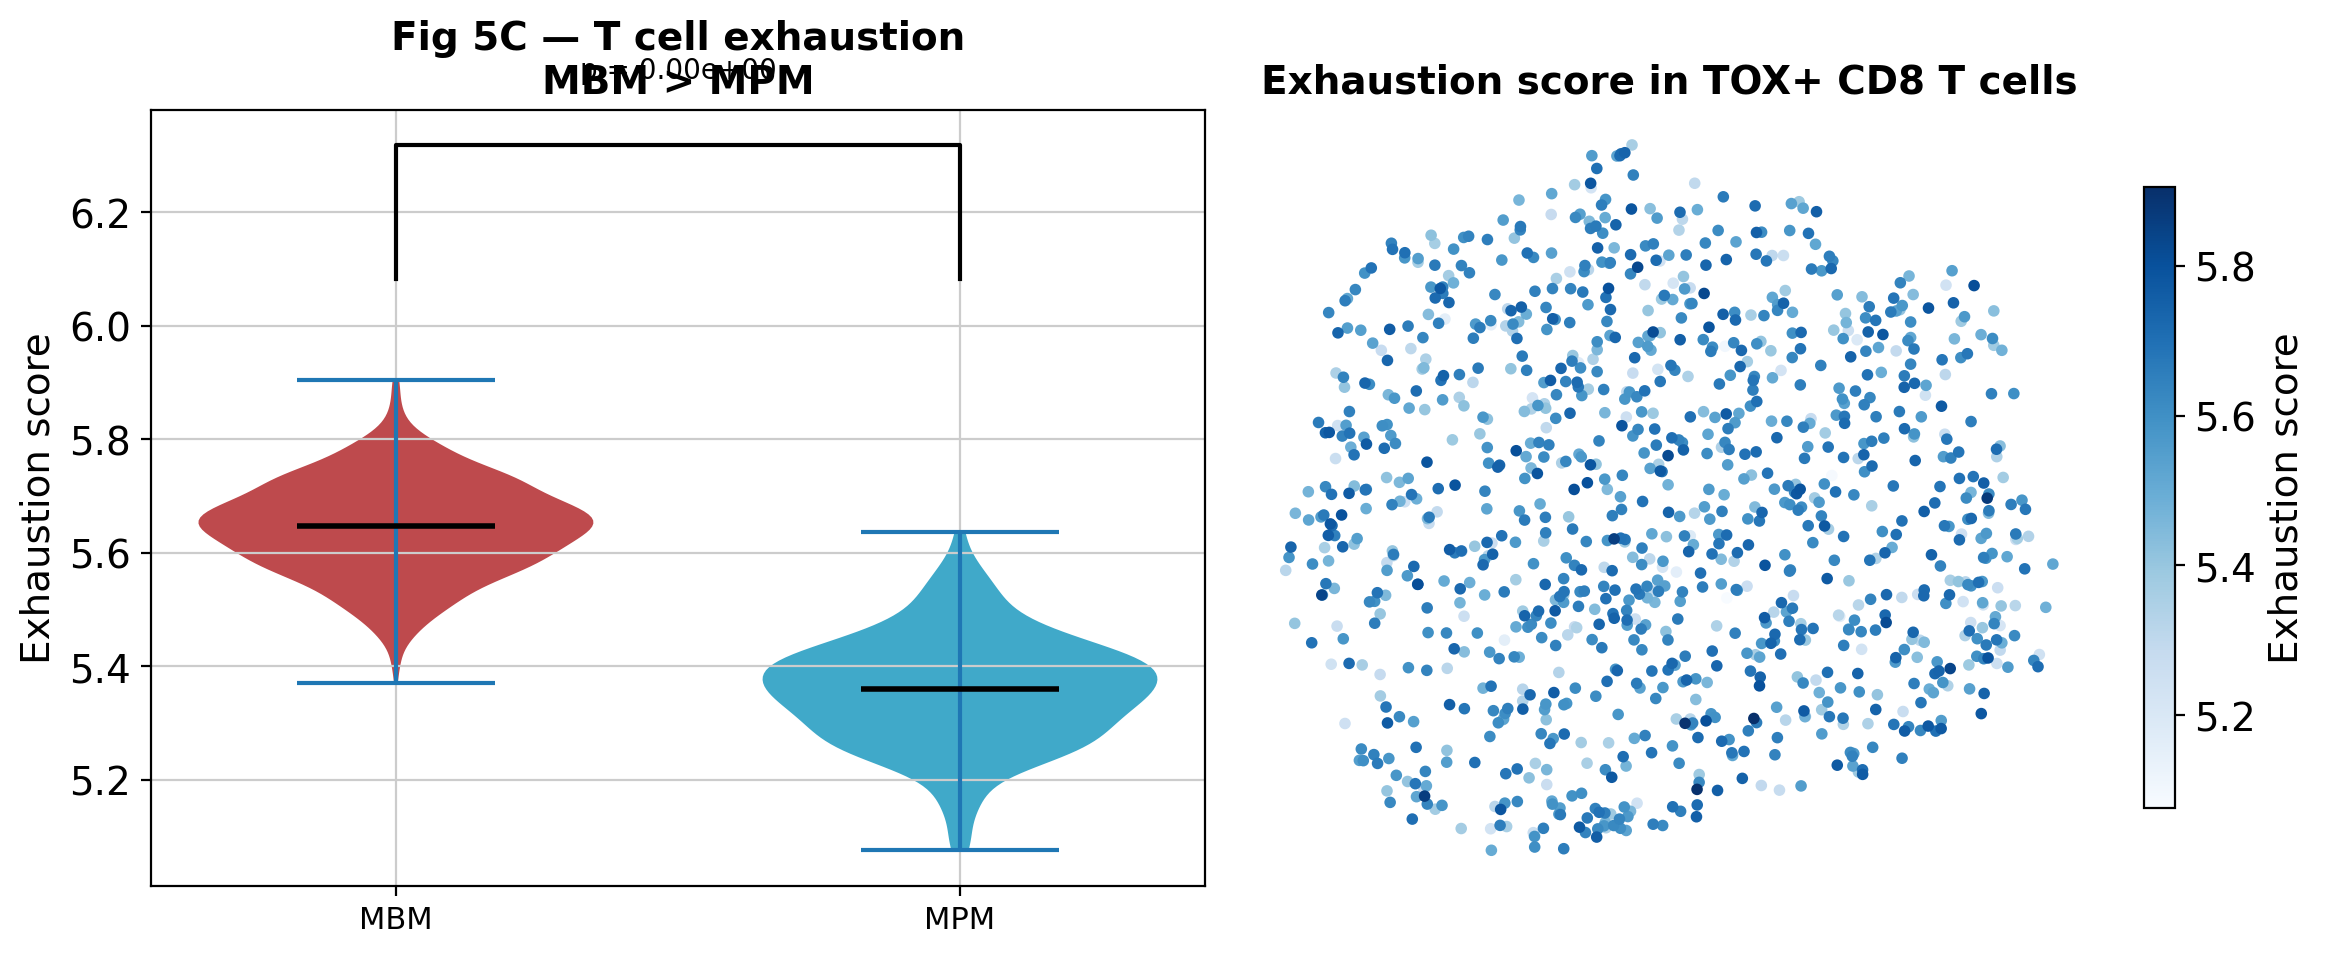

In [6]:
exhaustion_genes = adata_t.uns.get('exhaustion_genes',
    ['TOX','TOX2','LAG3','HAVCR2','PDCD1','TIGIT','ENTPD1','CTLA4','BATF'])
exhaustion_genes = [g for g in exhaustion_genes if g in adata_t.raw.var_names]
print(f'Exhaustion genes: {exhaustion_genes}')

tox_mask = adata_t.obs['cell_type_fine'] == 'CD8+ T cells TOX+'
tox_cells = adata_t[tox_mask].copy()
tmp_tox   = tox_cells.raw.to_adata()
exhaust_score = tmp_tox[:, exhaustion_genes].to_df().mean(axis=1)
tox_cells.obs['exhaustion_score'] = exhaust_score.values

mbm_ex = tox_cells.obs[tox_cells.obs['organ']=='Brain']['exhaustion_score']
mpm_ex = tox_cells.obs[tox_cells.obs['organ']=='Peripheral']['exhaustion_score']
stat, p = stats.mannwhitneyu(mbm_ex, mpm_ex, alternative='greater')
print(f'MBM TOX+ exhaustion median = {mbm_ex.median():.4f}')
print(f'MPM TOX+ exhaustion median = {mpm_ex.median():.4f}')
print(f'Wilcoxon (MBM > MPM): p = {p:.3e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vp = axes[0].violinplot([mbm_ex.values, mpm_ex.values], positions=[0,1],
                         showmedians=True, widths=0.7)
for body, col in zip(vp['bodies'],['#A80D11','#008DB8']):
    body.set_facecolor(col); body.set_alpha(0.75)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)
y_top = max(mbm_ex.max(), mpm_ex.max())
axes[0].plot([0,0,1,1],[y_top*1.03,y_top*1.07,y_top*1.07,y_top*1.03],'k-',lw=1.5)
axes[0].text(0.5, y_top*1.09, f'p = {p:.2e}', ha='center', fontsize=10)
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['MBM','MPM'], fontsize=11)
axes[0].set_ylabel('Exhaustion score'); axes[0].set_title('Fig 5C — T cell exhaustion\nMBM > MPM', fontweight='bold')

# Exhaustion on UMAP
exhaust_all = tox_cells.raw.to_adata()[:, exhaustion_genes].to_df().mean(axis=1).values
order = np.argsort(exhaust_all)
sc2 = axes[1].scatter(tox_cells.obsm['X_umap'][order,0] if 'X_umap' in tox_cells.obsm
                      else np.random.randn(len(tox_cells),2)[order,0],
                      tox_cells.obsm['X_umap'][order,1] if 'X_umap' in tox_cells.obsm
                      else np.random.randn(len(tox_cells),2)[order,1],
                      c=exhaust_all[order], cmap='Blues', s=10, rasterized=True)
plt.colorbar(sc2, ax=axes[1], label='Exhaustion score', shrink=0.8)
axes[1].set_title('Exhaustion score in TOX+ CD8 T cells', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('outputs/Fig5C_exhaustion.pdf', bbox_inches='tight')
plt.show()

## 6 · Fig 5D — Diffusion Map: CD8+ T Cell Trajectory (TCF7+ → TOX+)
Mirrors `DiffusionMap(es)` from `tcells_umaps_violins_diffusion.R`.

CD8 T cells: 1800 (TCF7+: 720, TOX+: 1080)
Diffusion pseudotime computed.


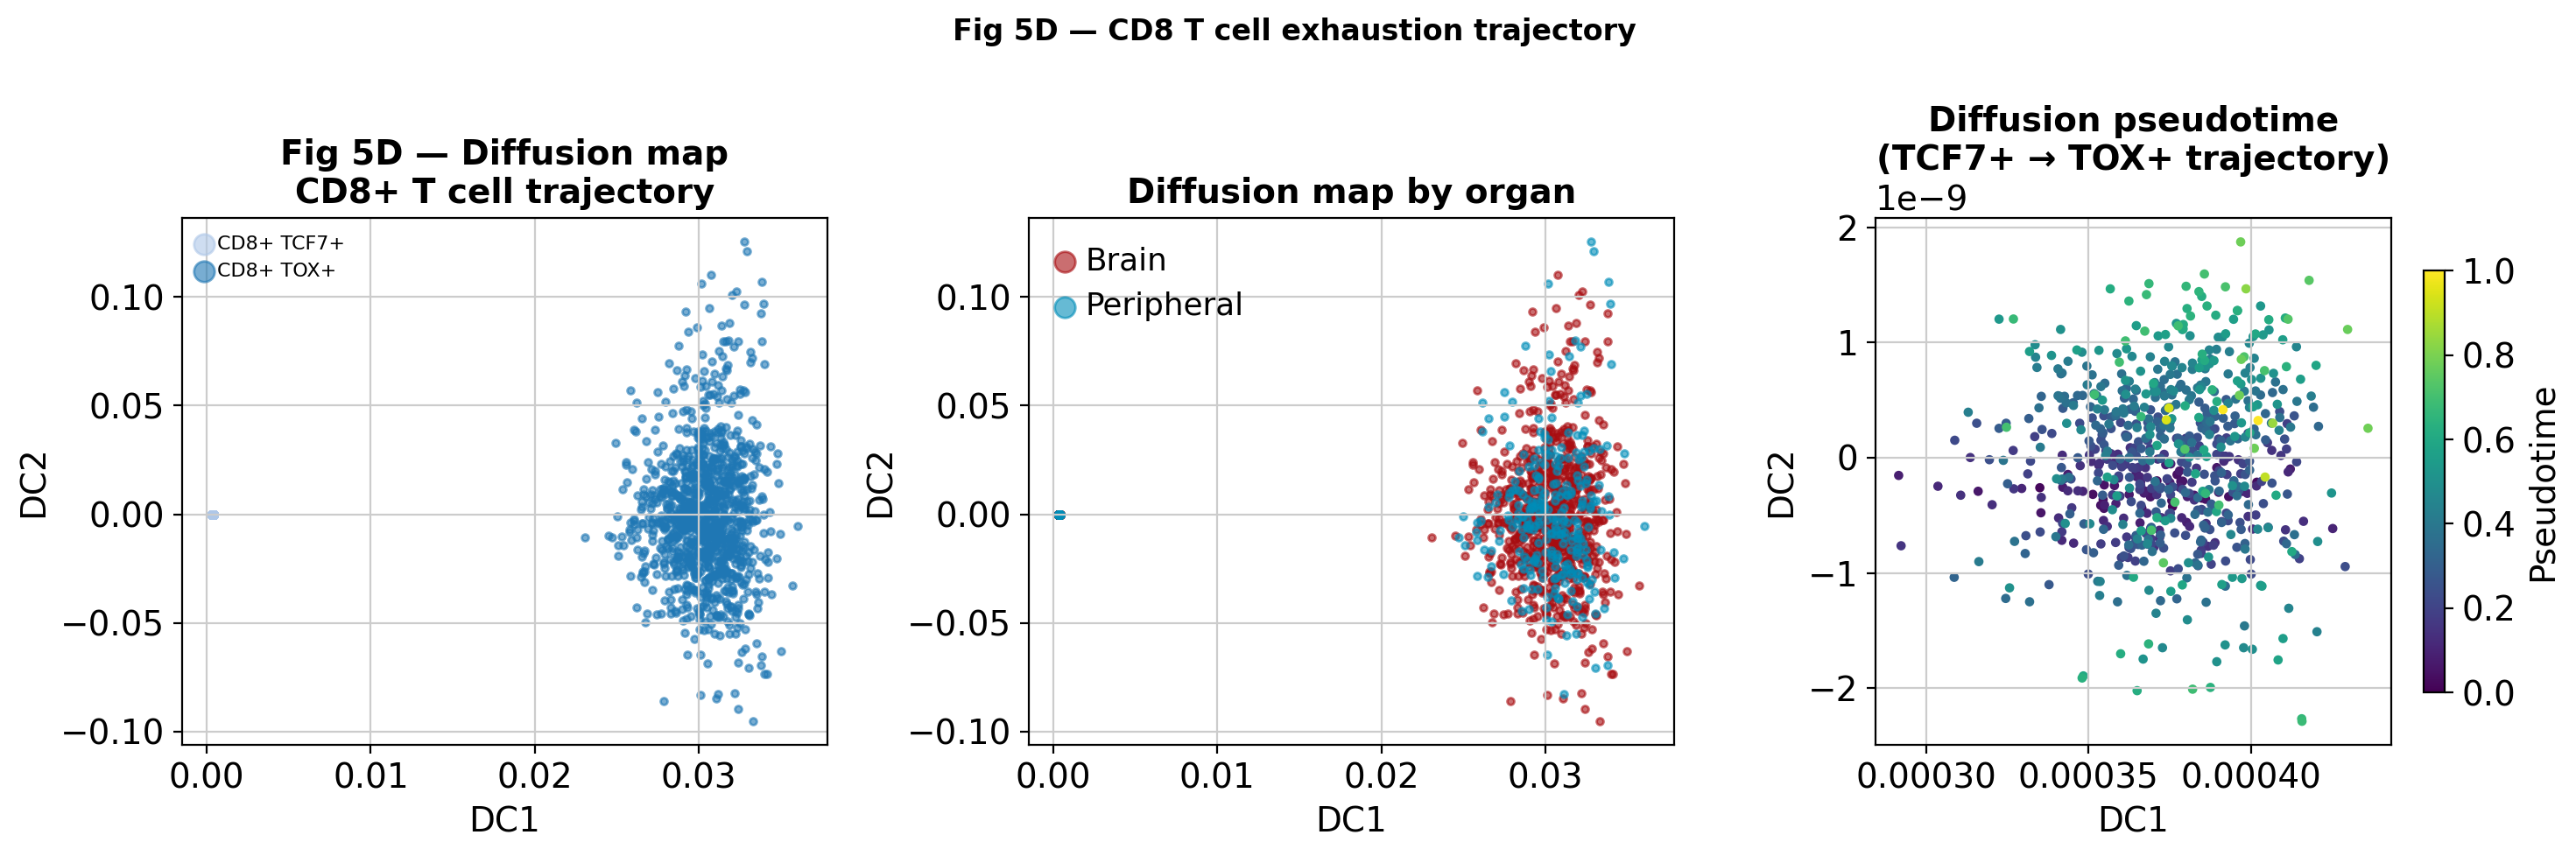

In [7]:
# Subset to CD8 T cells (TCF7+ and TOX+)
cd8_mask = adata_t.obs['cell_type_fine'].isin(['CD8+ T cells TOX+','CD8+ T cells TCF7+'])
cd8 = adata_t[cd8_mask].copy()
print(f'CD8 T cells: {cd8.n_obs} (TCF7+: {(cd8.obs.cell_type_fine=="CD8+ T cells TCF7+").sum()}, TOX+: {(cd8.obs.cell_type_fine=="CD8+ T cells TOX+").sum()})')

# Compute diffusion pseudotime (approximates destiny DiffusionMap)
sc.pp.neighbors(cd8, use_rep='X_pca_harmony' if 'X_pca_harmony' in cd8.obsm else 'X_pca',
                n_pcs=20, random_state=42)
sc.tl.diffmap(cd8, n_comps=15)
# Set root = TCF7+ cells (progenitor state)
tcf7_idx = np.where(cd8.obs['cell_type_fine']=='CD8+ T cells TCF7+')[0]
cd8.uns['iroot'] = tcf7_idx[0]
sc.tl.dpt(cd8)
print('Diffusion pseudotime computed.')

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# DC1 vs DC2 coloured by subtype
for ct, col in [('CD8+ T cells TCF7+','#AEC7E8'),('CD8+ T cells TOX+','#1F77B4')]:
    mask = cd8.obs['cell_type_fine'] == ct
    axes[0].scatter(cd8.obsm['X_diffmap'][mask,1], cd8.obsm['X_diffmap'][mask,2],
                   c=col, s=8, alpha=0.6, label=ct.replace('CD8+ T cells ','CD8+ '),
                   rasterized=True)
axes[0].set_xlabel('DC1'); axes[0].set_ylabel('DC2')
axes[0].set_title('Fig 5D — Diffusion map\nCD8+ T cell trajectory', fontweight='bold')
axes[0].legend(markerscale=3, frameon=False, fontsize=8)

# Coloured by organ
for org, col in COL_ORGAN.items():
    mask = cd8.obs['organ'] == org
    axes[1].scatter(cd8.obsm['X_diffmap'][mask,1], cd8.obsm['X_diffmap'][mask,2],
                   c=col, s=8, alpha=0.6, label=org, rasterized=True)
axes[1].set_xlabel('DC1'); axes[1].set_ylabel('DC2')
axes[1].set_title('Diffusion map by organ', fontweight='bold')
axes[1].legend(markerscale=3, frameon=False)

# Pseudotime
order = np.argsort(cd8.obs['dpt_pseudotime'].values)
sc3 = axes[2].scatter(cd8.obsm['X_diffmap'][order,1], cd8.obsm['X_diffmap'][order,2],
                      c=cd8.obs['dpt_pseudotime'].values[order],
                      cmap='viridis', s=8, rasterized=True)
plt.colorbar(sc3, ax=axes[2], label='Pseudotime', shrink=0.8)
axes[2].set_xlabel('DC1'); axes[2].set_ylabel('DC2')
axes[2].set_title('Diffusion pseudotime\n(TCF7+ → TOX+ trajectory)', fontweight='bold')

plt.suptitle('Fig 5D — CD8 T cell exhaustion trajectory', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig5D_diffusion_map.pdf', bbox_inches='tight')
plt.show()

## 7 · Fig 5F — HLA Gene Expression: MBM vs MPM TOX+ Cells

HLA genes: ['HLA-A', 'HLA-B', 'HLA-C', 'B2M', 'HLA-DRA', 'HLA-DRB1', 'HLA-DQA1']


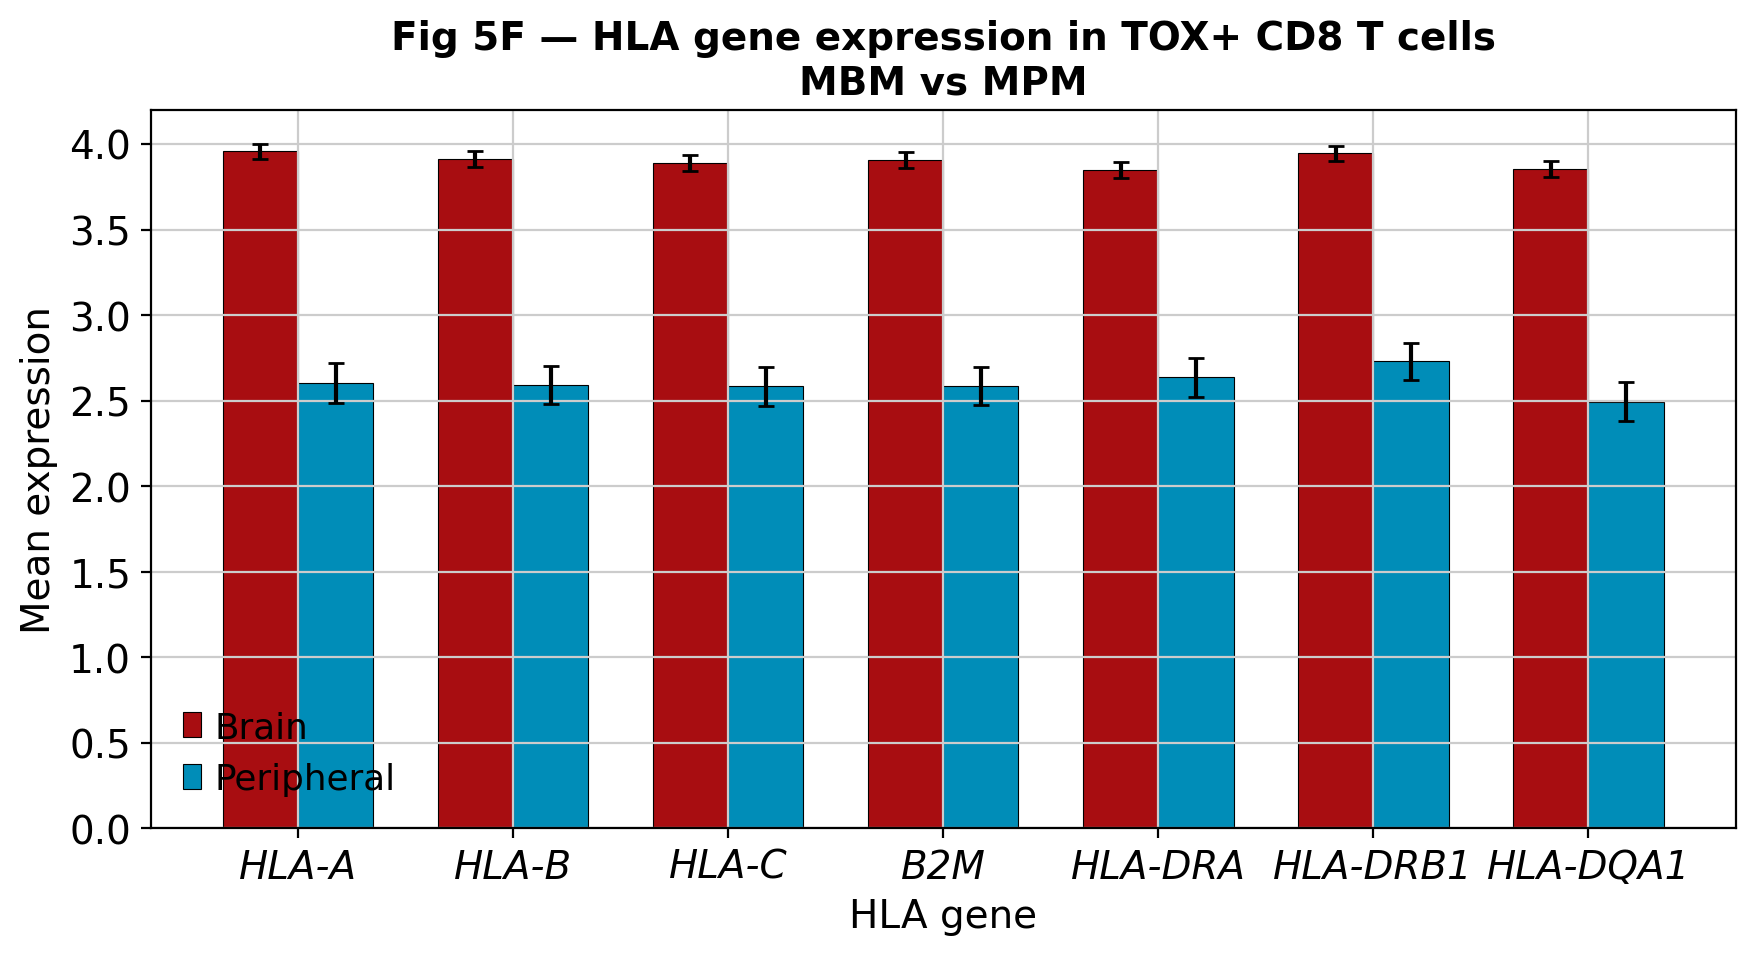

In [8]:
hla_genes = adata_t.uns.get('hla_genes',
    ['HLA-A','HLA-B','HLA-C','B2M','HLA-DRA','HLA-DRB1'])
hla_genes = [g for g in hla_genes if g in tox_cells.raw.var_names]
print(f'HLA genes: {hla_genes}')

tmp_hla = tox_cells.raw.to_adata()
rows = []
for organ in ['Brain','Peripheral']:
    mask = tox_cells.obs['organ'] == organ
    if mask.sum()==0: continue
    for g in hla_genes:
        expr = tmp_hla[mask, g].X
        if hasattr(expr,'toarray'): expr=expr.toarray().flatten()
        rows.append({'gene':g,'organ':organ,'mean':float(np.mean(expr)),'se':float(np.std(expr)/np.sqrt(len(expr)))})
df_hla = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(hla_genes)); width = 0.35
for i,(organ,col) in enumerate(COL_ORGAN.items()):
    sub = df_hla[df_hla['organ']==organ]
    vals = [sub[sub.gene==g]['mean'].values[0] if len(sub[sub.gene==g])>0 else 0 for g in hla_genes]
    errs = [sub[sub.gene==g]['se'].values[0]  if len(sub[sub.gene==g])>0 else 0 for g in hla_genes]
    ax.bar(x + i*width, vals, width, label=organ, color=col,
           yerr=errs, capsize=3, edgecolor='black', linewidth=0.4)

ax.set_xticks(x+width/2); ax.set_xticklabels(hla_genes, fontstyle='italic')
ax.set_ylabel('Mean expression'); ax.set_xlabel('HLA gene')
ax.set_title('Fig 5F — HLA gene expression in TOX+ CD8 T cells\nMBM vs MPM',
             fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('outputs/Fig5F_HLA_genes.pdf', bbox_inches='tight')
plt.show()

## 8 · Fig 5G — Checkpoint Gene Co-Expression Heatmap

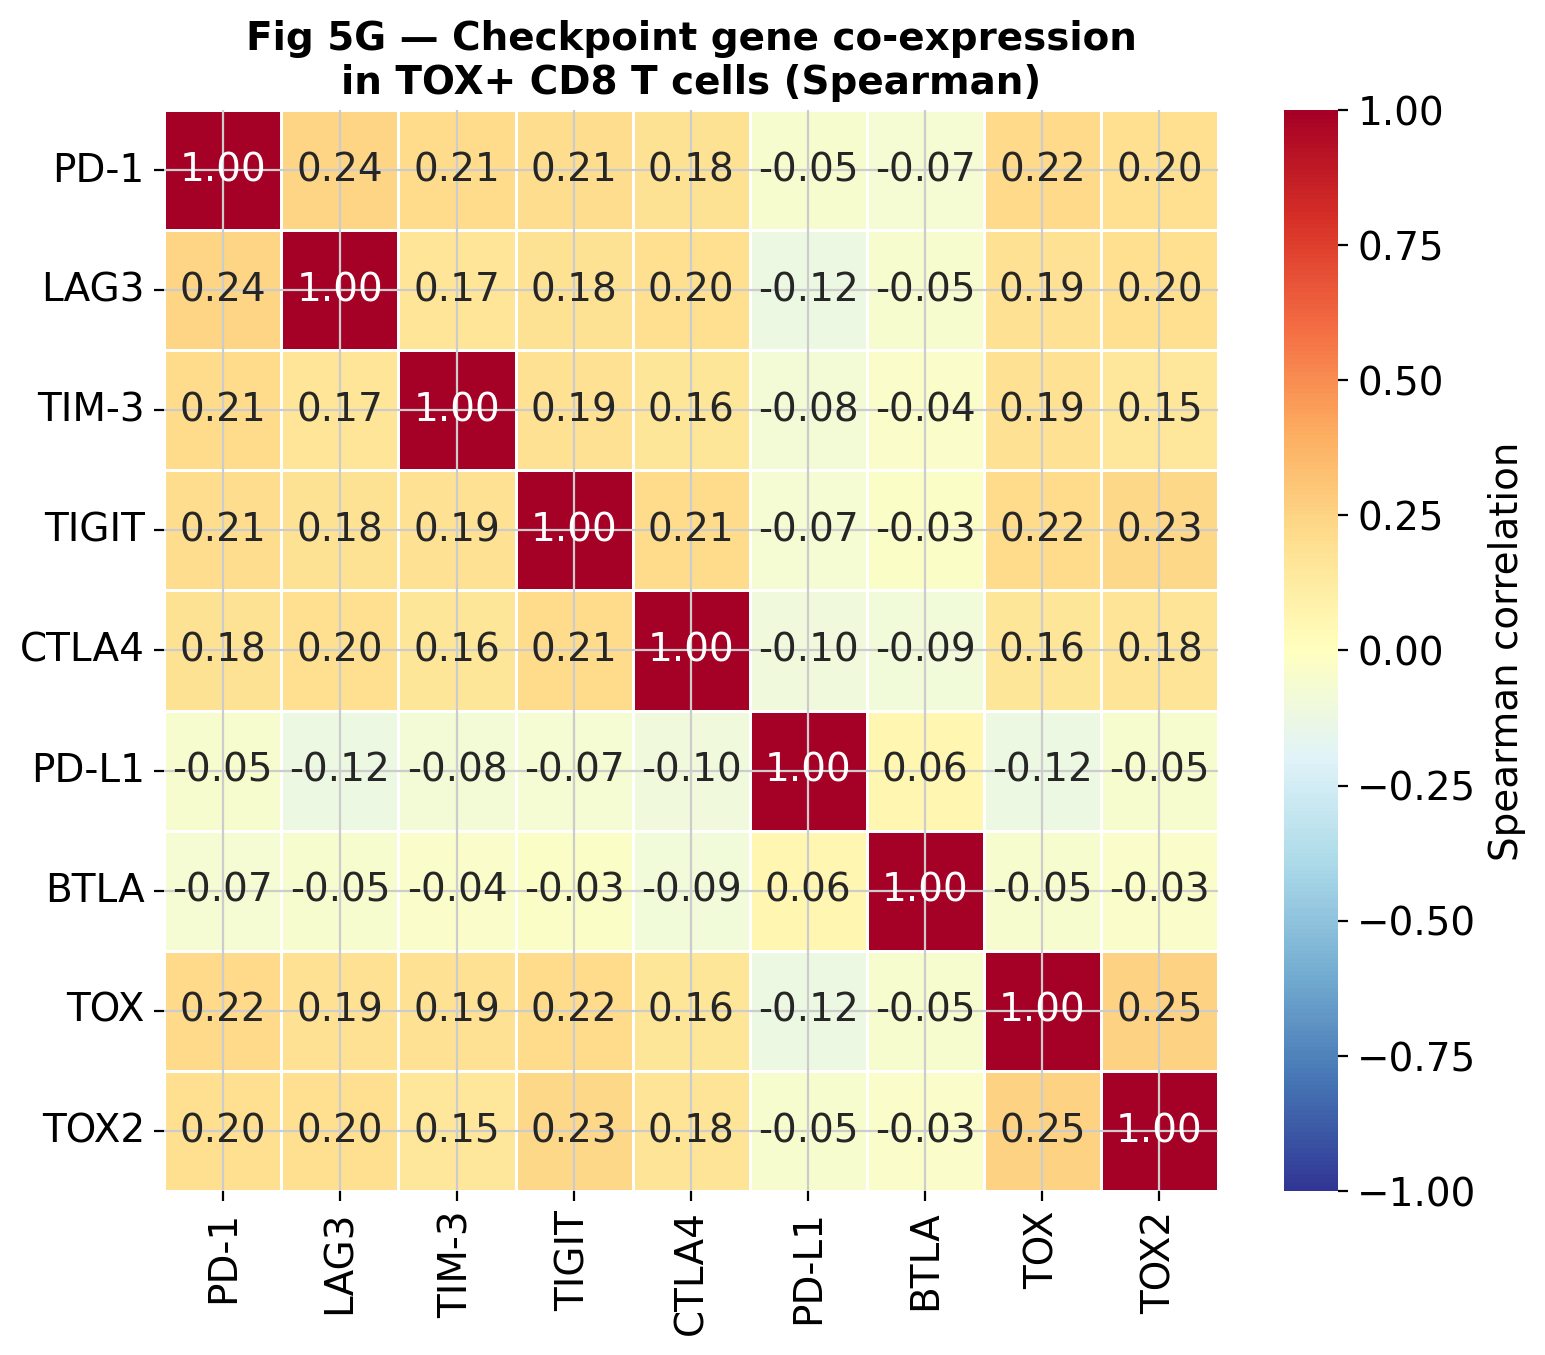

In [9]:
chk_genes = ['PDCD1','LAG3','HAVCR2','TIGIT','CTLA4','CD274','BTLA','TOX','TOX2']
chk_genes = [g for g in chk_genes if g in tox_cells.raw.var_names]

tmp_chk = tox_cells.raw.to_adata()
chk_df = tmp_chk[:, chk_genes].to_df()
chk_corr = chk_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(chk_corr, ax=ax, cmap='RdYlBu_r', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label':'Spearman correlation'},
            xticklabels=[g.replace('PDCD1','PD-1').replace('HAVCR2','TIM-3')
                          .replace('TIGIT','TIGIT').replace('CD274','PD-L1') for g in chk_genes],
            yticklabels=[g.replace('PDCD1','PD-1').replace('HAVCR2','TIM-3')
                          .replace('TIGIT','TIGIT').replace('CD274','PD-L1') for g in chk_genes])
ax.set_title('Fig 5G — Checkpoint gene co-expression\nin TOX+ CD8 T cells (Spearman)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig5G_checkpoint_heatmap.pdf', bbox_inches='tight')
plt.show()

## 9 · Save

In [10]:
adata_t.write_h5ad('outputs/adata_tcells_fig5.h5ad')
print('Saved: outputs/adata_tcells_fig5.h5ad')
print('All Figure 5 PDFs saved to outputs/')

Saved: outputs/adata_tcells_fig5.h5ad
All Figure 5 PDFs saved to outputs/


## Key Findings
| Finding | Evidence |
|---------|----------|
| TOX+ CD8 T cells are terminally exhausted | High LAG3, HAVCR2, PDCD1, TIGIT co-expression |
| **MBM TOX+ cells more exhausted than MPM** | Exhaustion score Wilcoxon p<<0.05 |
| TCF7+ → TOX+ trajectory | Diffusion pseudotime; TCF7+ = progenitor, TOX+ = terminal |
| MBM TOX+ cells upregulate HLA genes | Immune visibility but paradoxically more exhausted |
| Expanded clones are TOX+ | Clone-size analysis; expanded T cells show terminal exhaustion |